<a href="https://colab.research.google.com/github/mewspiritwo/Basic-Mathematical-Modeling/blob/programming-homeworks/homework_11_DNA_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Genes are composed of DNA and therefore contain sequences of the following nucleotides:
- ${\text A}$: adenine
- ${\text G}$: guanine
- ${\text C}$: cytosine
- ${\text T}$: thymine

A segment of a gene can be represented by its sequence, for example,

$$\text{Gene} \equiv \dots\text{ATGCACTGA}\dots$$

The enzyme RNA polymerase makes copies of these sequences through the formation of messenger RNA (mRNA) in which the nucleotide $\text{T}$ is replaced by uracil $\text{U}$. The mRNA copies are then sent to the ribosomes where proteins are created that fulfill the function dictated by the gene (create black eyes, red hair, etc.).

However, when this transcription process occurs, certain “errors” may occur when copying a nucleotide, altering the mRNA sequence and resulting in alterations in the functions of the proteins that are generated from it.


Suppose you want to estimate the probability of a nucleotide change in mRNA consisting of n=9 nucleotides. To do this, the number of nucleotides that have changed during the transcription process is defined as a random variable.

Several copies of mRNA corresponding to this gene are analyzed, and the number of alterations in the sequence is counted in each one. For example,
mRNA-0=AUGCACUGA
mRNA-1=AUGCACUGA
mRNA-2=AUGCGCUGA
compare the original with two samples, the first of which has no changes, while the second has one change. The results obtained for N=10 samples are as follows:

|   Sample  | Number of alterations |
|:-----------:|:------:|
|  Sample 1  |   2   |
|  Sample 2  |   1   |
|  Sample 3  |   2   |
|  Sample 4  |   5   |
|  Sample 5  |   2   |
|  Sample 6  |   1   |
|  Sample 7  |   3   |
|  Sample 8  |   1   |
|  Sample 9  |   1   |
| Sample 10  |   4   |




### Problem Set:

Using a binomial distribution, construct a stochastic model for the above problem, answering the following questions:

* **Point 1**: Define the random variable for the stochastic model and state the possible values it can take.

* **Point 2**: Estimate the probability $p$ of a nucleotide change in the mRNA transcription process.

* **Point 3**: Calculate the probability that a randomly selected copy of the gene's messenger RNA will not have any alterations.

* **Point 4**: Calculate the probability that when randomly selecting a copy of the messenger RNA of the gene, it will have alterations, that is, **at least** one of its nucleotides has changed.

* **Point 5**: Make a graph showing the percentage probability of $m \in \{0,1,2,\dots,n=9\}$ alterations occurring in the mRNA sequence.


# Problem Solving

1. **The random variable** in the stochastic model is the number of nucleotides that have changed during the transcription process, that is:

$$m \in \{0,1,2,\dots,n=9\}$$

Where $0$ means that there is no alteration, and the possible alterations range from $m \geq 1$ to $9$.

2. Given that there are only two probabilities: **that it will be altered: $p$** and **that it will not be altered $(1-p)$**. Therefore, the binomial distribution will be used to estimate the probability of nucleotide change and, consequently, alteration of the mRNA.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom     # Allows calculating the PMF (Probability Mass Function)

n = 9                             # Random variable: number of nucleotides

number_of_alterations = [2, 1, 2, 5, 2, 1, 3, 1, 1, 4]
# Array that organizes the alterations per sample

sample_mean = np.mean(number_of_alterations)
# Use the function to compute the sample mean of all alterations

probability_of_change = sample_mean / n
# Estimate the "global" probability

print("The sample mean is:", sample_mean, "alterations.")
print("The estimated probability of change is:", round(probability_of_change, 4))


The sample mean is: 2.2 alterations.
The estimated probability of change is: 0.2444


3. The probability that no alteration will occur is expressed as follows:

$$P(X = m) = \binom{n}{m}p^{m} (1 - p)^{n-m}$$

$$P(X = 0) = \binom{n}{0}p^{0} (1 - p)^{9-0}$$

$$P(X = 0) = 1 \cdot 1 \cdot (1 - p)^{9}$$

$$P(X = 0) = (1 - p)^{9}$$

In [3]:
# The probability of having zero alterations in any given sample is calculated
probability_zero = binom.pmf(0, 9, probability_of_change)
percentage = probability_zero * 100

# The result is printed
print(
    'The probability that a copy presents no alterations is',
    round(probability_zero, 4),
    'or in percentage',
    round(percentage, 4),
    '%'
)


The probability that a copy presents no alterations is 0.0802 or in percentage 8.0241 %


4. Knowing from the previous code that the probability of not obtaining any alteration is:

$$P(X = 0) = (1 - p)^{9}$$

The probability that there is at least one alteration is the complement of the probability that there are none:

$$ P(X \ge 1) = 1 - P(X = 0) = 1 - (1 - p)^{n}$$

In [4]:
## Now the probability that at least one nucleotide has changed is calculated
probability_at_least_one = 1 - probability_zero
percentage_at_least_one = probability_at_least_one * 100

# The result is printed
print(
    'The probability that there is at least one alteration is',
    round(probability_at_least_one, 4),
    'or in percentage',
    round(percentage_at_least_one, 4),
    '%'
)


The probability that there is at least one alteration is 0.9198 or in percentage 91.9759 %


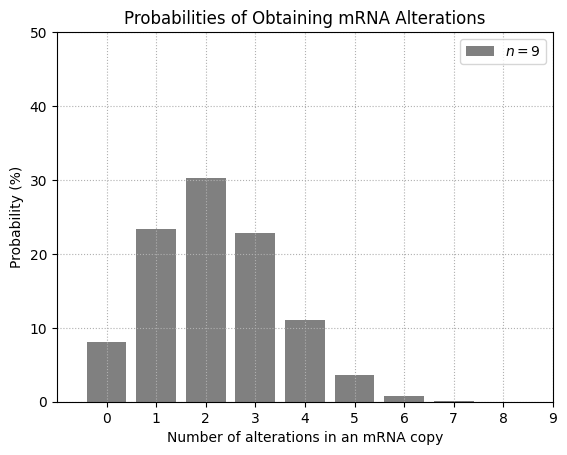

In [5]:
# Parameters are prepared for plotting
alterations = np.arange(n + 1)
probabilities = binom.pmf(alterations, n, probability_of_change)

# The plot is created
plt.bar(alterations, 100 * probabilities, color='gray', label='$n=$' + str(n))
plt.title("Probabilities of Obtaining mRNA Alterations")
plt.ylabel("Probability (%)")
plt.xlabel("Number of alterations in an mRNA copy")
plt.xlim([-1, n])
plt.ylim([0, 50])
# It should range from 0 to 100 for percentage probability, however the maximum is approximately 30%
plt.xticks(range(0, n + 1, 1))
plt.legend()
plt.grid(linestyle=':')
plt.show()
